# Notebook de Recherche : Deep Learning LSTM pour la Prediction de Prix
Ce notebook accompagne **QC-Py-22-Deep-Learning-LSTM** et demontre le workflow complet
d'entrainement d'un modele LSTM avec PyTorch dans l'environnement QuantBook.

## Objectifs d'apprentissage

- Charger et preparer des donnees de prix avec MinMaxScaler
- Creer des sequences temporelles pour l'entree LSTM
- Definir et entrainer un modele LSTM avec PyTorch
- Evaluer les performances et visualiser les predictions
- Sauvegarder le modele via ObjectStore pour l'integration dans main.py

**Duree estimee** : 60 minutes

**Prerequis** : QC-Py-04-Research-Workflow, bases de PyTorch

---
## 1. Configuration et Imports

Import des librairies necessaires et configuration de l'environnement QuantBook.

In [1]:
# Imports QuantBook
from QuantConnect.Research import QuantBook
from QuantConnect import Resolution

# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-whitegrid')

print("Imports termines avec succes")

Imports termines avec succes


On charge ici les données historiques de marché nécessaires à l'entraînement du réseau de neurones LSTM.

In [2]:
# Import PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Verification du device (CPU dans QuantBook)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device utilise: {device}")

PyTorch version: 2.8.0+cu128
Device utilise: cpu


---
## 2. Chargement des Donnees

Utilisation de QuantBook pour recuperer l'historique des prix de SPY.

In [3]:
# Initialisation QuantBook
qb = QuantBook()

# Ajout de l'actif
symbol = qb.add_equity("SPY", Resolution.DAILY).symbol

# Recuperation de l'historique (3 ans)
history = qb.history(symbol, 252 * 3, Resolution.DAILY)

# Extraction des prix de cloture
if isinstance(history.index, pd.MultiIndex):
    prices = history['close'].xs(symbol, level=0)
else:
    prices = history['close']

prices = prices.sort_index()
print(f"Donnees chargees: {len(prices)} jours")
print(f"Periode: {prices.index[0].date()} a {prices.index[-1].date()}")
prices.head()

Donnees chargees: 756 jours
Periode: 2023-06-05 a 2026-06-09


time
2023-06-05 16:00:00    411.000978
2023-06-06 16:00:00    411.895923
2023-06-07 16:00:00    410.471710
2023-06-08 16:00:00    412.954460
2023-06-09 16:00:00    413.695435
Name: close, dtype: float64

On normalise et structure les séquences temporelles pour les adapter au format d'entrée du modèle LSTM.

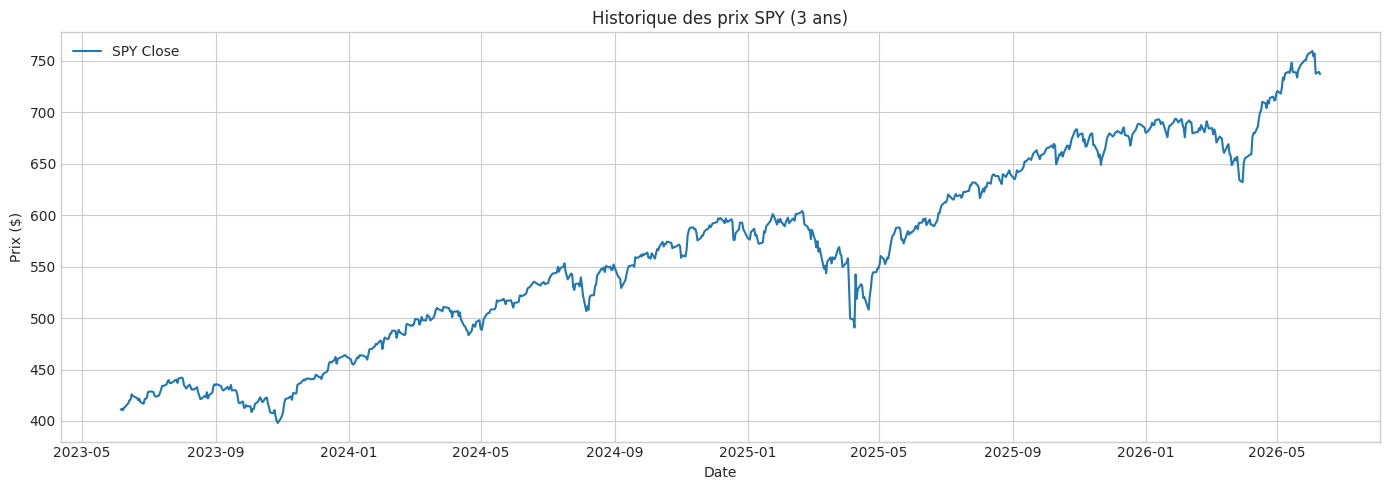

In [4]:
# Visualisation des prix
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prices.index, prices.values, label='SPY Close', linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.set_title('Historique des prix SPY (3 ans)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Pretraitement et Creation de Sequences

Normalisation des donnees et creation des fenetres glissantes pour LSTM.

In [5]:
# Normalisation MinMax [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.values.reshape(-1, 1))

print(f"Forme des donnees normalisees: {prices_scaled.shape}")
print(f'Plage: [{prices_scaled.min():.4f}, {prices_scaled.max():.4f}]')

Forme des donnees normalisees: (756, 1)
Plage: [0.0000, 1.0000]


On construit l'architecture du réseau LSTM avec ses couches récurrentes et les couches denses de sortie.

In [6]:
def create_sequences(data, seq_length):
    """
    Cree des sequences pour l'entree LSTM.
    
    Args:
        data: Donnees normalisees (n_samples, n_features)
        seq_length: Longueur de la sequence (fenetre)
    
    Returns:
        X: Sequences d'entree (n_samples, seq_length, n_features)
        y: Cibles (n_samples, n_features)
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Parametres
SEQ_LENGTH = 60  # 60 jours de lookback

# Creation des sequences
X, y = create_sequences(prices_scaled, SEQ_LENGTH)

print(f"Forme X: {X.shape}  (samples, sequence_length, features)")
print(f"Forme y: {y.shape}  (samples, features)")

Forme X: (696, 60, 1)  (samples, sequence_length, features)
Forme y: (696, 1)  (samples, features)


### Comprendre la forme des donnees

Pour un LSTM, l'entree doit avoir 3 dimensions:
- **samples**: Nombre de sequences d'entrainement
- **sequence_length**: Nombre de pas de temps (jours) par sequence
- **features**: Nombre de variables par pas de temps (1 = prix de cloture)

Avec 756 jours et seq_length=60, nous obtenons 696 sequences.

In [7]:
# Division temporelle (pas de shuffle pour series temporelles)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversion en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")

Train: torch.Size([556, 60, 1]), Test: torch.Size([140, 60, 1])


---
## 4. Definition du Modele LSTM

Architecture LSTM avec couche lineaire finale pour la prediction.

In [8]:
class LSTMModel(nn.Module):
    """
    Modele LSTM pour prediction de series temporelles.
    
    Architecture:
    - Couche LSTM avec hidden_size neurones
    - Dropout pour regularisation
    - Couche lineaire pour sortie (prediction)
    """
    
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Couche LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Couche de sortie
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        
        # LSTM forward
        lstm_out, _ = self.lstm(x)
        
        # Prendre seulement le dernier output
        last_out = lstm_out[:, -1, :]
        
        # Couche lineaire
        prediction = self.fc(last_out)
        
        return prediction

# Instanciation du modele
model = LSTMModel(
    input_size=1,
    hidden_size=50,
    num_layers=2,
    output_size=1,
    dropout=0.2
).to(device)

print(model)
print(f"\nNombre de parametres: {sum(p.numel() for p in model.parameters()):,}")

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

Nombre de parametres: 31,051


---
## 5. Entrainement du Modele

Boucle d'entrainement avec loss MSE et optimiseur Adam.

In [9]:
# Hyperparametres
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 32

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Loss et optimiseur
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

On entraîne le modèle LSTM sur les données d'apprentissage en optimisant la fonction de perte par descente de gradient.

In [10]:
# Boucle d'entrainement
train_losses = []

print("Debut de l'entrainement...\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.6f}")

print("\nEntrainement termine!")

Debut de l'entrainement...



Epoch [20/100], Loss: 0.001249


Epoch [40/100], Loss: 0.000888


Epoch [60/100], Loss: 0.000791


Epoch [80/100], Loss: 0.000699


Epoch [100/100], Loss: 0.000629

Entrainement termine!


On évalue les prédictions du LSTM sur l'ensemble de validation pour mesurer la précision du modèle.

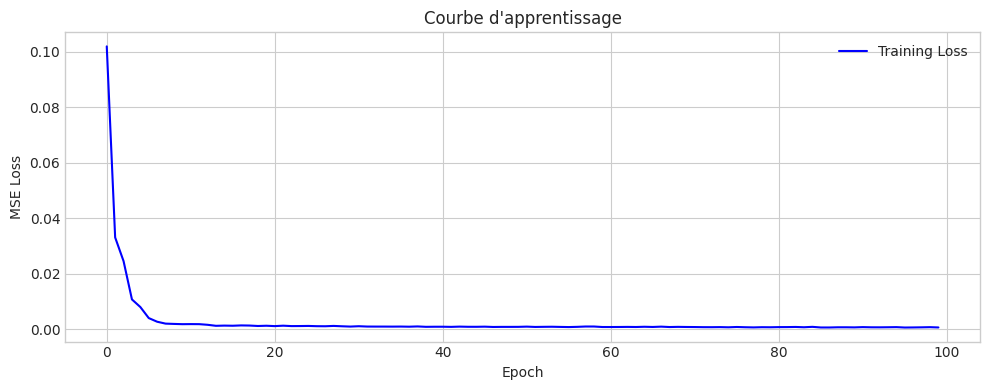

In [11]:
# Visualisation de la loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Training Loss', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title("Courbe d'apprentissage")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Evaluation et Visualisation

Prediction sur l'ensemble de test et calcul des metriques.

In [12]:
# Modele en mode evaluation
model.eval()

with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()

# Inverse transformation pour obtenir les prix reels
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Calcul du RMSE
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"RMSE sur l'ensemble de test: ${rmse:.2f}")

# Calcul du MAPE
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
print(f"MAPE: {mape:.2f}%")

RMSE sur l'ensemble de test: $10.14
MAPE: 1.21%


On visualise les prédictions du modèle par rapport aux valeurs réelles pour analyser la qualité des signaux générés.

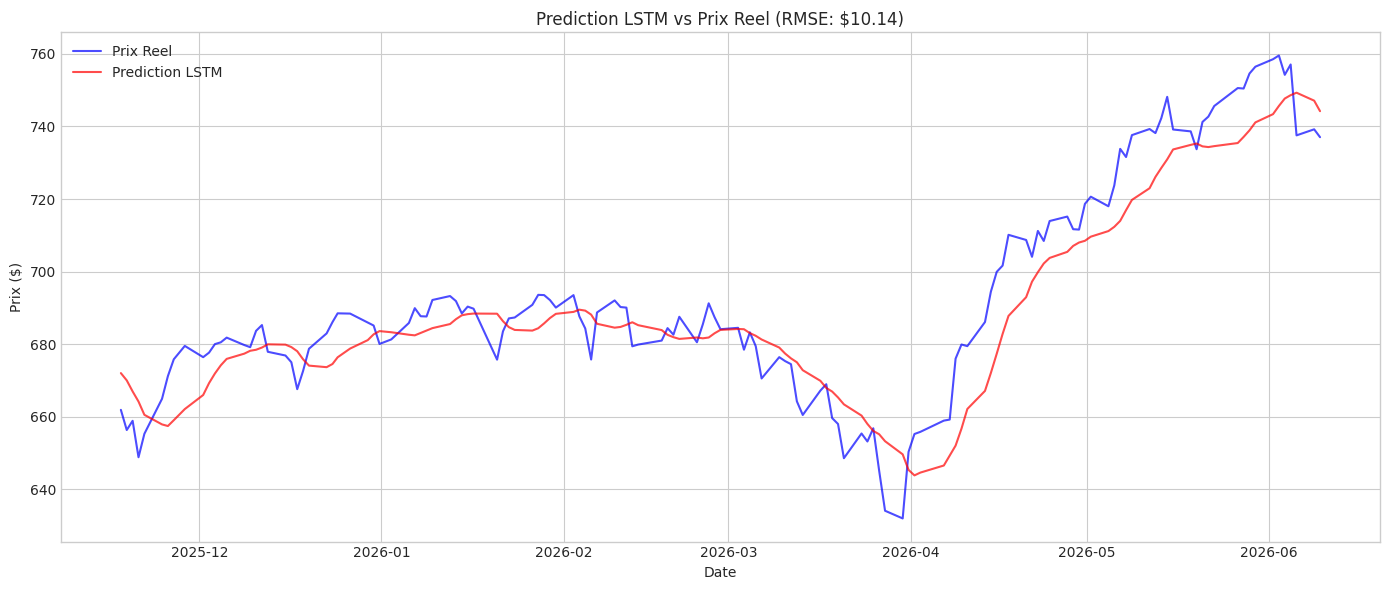

In [13]:
# Visualisation des predictions
test_dates = prices.index[train_size + SEQ_LENGTH:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, y_actual, label='Prix Reel', color='blue', alpha=0.7)
ax.plot(test_dates, y_pred, label='Prediction LSTM', color='red', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.set_title(f'Prediction LSTM vs Prix Reel (RMSE: ${rmse:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

On génère les signaux de trading à partir des prédictions du LSTM et on les intègre dans la stratégie algorithmique.

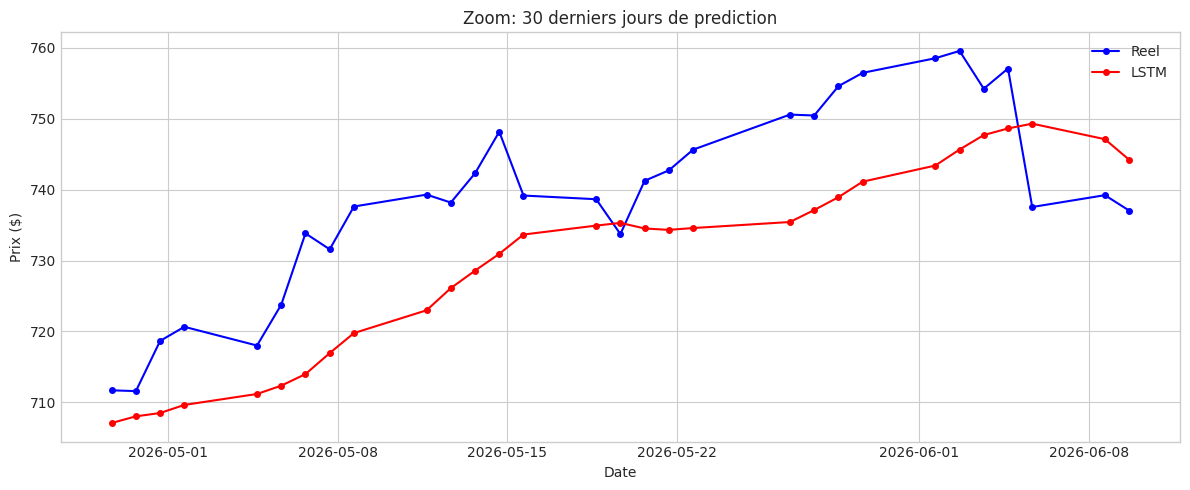

In [14]:
# Zoom sur les 30 derniers jours
zoom_days = 30

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates[-zoom_days:], y_actual[-zoom_days:], 
        'o-', label='Reel', color='blue', markersize=4)
ax.plot(test_dates[-zoom_days:], y_pred[-zoom_days:], 
        'o-', label='LSTM', color='red', markersize=4)
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')
ax.set_title('Zoom: 30 derniers jours de prediction')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Sauvegarde via ObjectStore

Le modele est sauvegarde dans l'ObjectStore QuantConnect pour etre charge dans main.py.

In [15]:
import io

# Sauvegarde du modele dans un buffer
buffer = io.BytesIO()
torch.save({
    'model_state_dict': model.state_dict(),
    'hidden_size': 50,
    'num_layers': 2,
    'seq_length': SEQ_LENGTH,
    'scaler_min': scaler.data_min_[0],
    'scaler_max': scaler.data_max_[0]
}, buffer)

# Sauvegarde dans l'ObjectStore
qb.object_store.save_bytes('lstm_spy_model', buffer.getvalue())

print("Modele sauvegarde dans l'ObjectStore: lstm_spy_model")
print(f"Taille: {len(buffer.getvalue()) / 1024:.1f} KB")

Modele sauvegarde dans l'ObjectStore: lstm_spy_model
Taille: 125.2 KB


On évalue les performances de la stratégie LSTM sur les données hors échantillon pour valider la robustesse du modèle.

In [16]:
# Verification de la sauvegarde
saved_data = qb.object_store.read_bytes('lstm_spy_model')
print(f"Verification: {len(saved_data)} bytes lus depuis l'ObjectStore")

# Test de chargement
# weights_only=False : requis depuis PyTorch 2.6 car le checkpoint contient
# des scalaires numpy (scaler_min/max) en plus du state_dict ; source de
# confiance puisque genere par la cellule precedente.
test_buffer = io.BytesIO(saved_data)
checkpoint = torch.load(test_buffer, map_location=device, weights_only=False)
print(f"Checkpoint keys: {list(checkpoint.keys())}")

Verification: 128197 bytes lus depuis l'ObjectStore
Checkpoint keys: ['model_state_dict', 'hidden_size', 'num_layers', 'seq_length', 'scaler_min', 'scaler_max']


---
## 8. Integration dans main.py

Code a copier dans votre algorithme pour utiliser le modele.

In [17]:
# === CODE A COPIER DANS main.py ===

# Dans Initialize():
"""
def Initialize(self):
    # ... configuration standard ...
    
    # Charger le modele LSTM depuis ObjectStore
    model_bytes = self.object_store.read_bytes('lstm_spy_model')
    buffer = io.BytesIO(model_bytes)
    checkpoint = torch.load(buffer, map_location='cpu')
    
    self.lstm_model = LSTMModel(
        hidden_size=checkpoint['hidden_size'],
        num_layers=checkpoint['num_layers']
    )
    self.lstm_model.load_state_dict(checkpoint['model_state_dict'])
    self.lstm_model.eval()
    
    self.seq_length = checkpoint['seq_length']
    self.scaler_min = checkpoint['scaler_min']
    self.scaler_max = checkpoint['scaler_max']
    
    self.price_history = []
"""

# Dans OnData():
"""
def OnData(self, data):
    if "SPY" not in data:
        return
    
    # Ajouter le prix a l'historique
    self.price_history.append(data["SPY"].Close)
    
    if len(self.price_history) < self.seq_length:
        return
    
    # Preparer la sequence
    recent_prices = np.array(self.price_history[-self.seq_length:])
    normalized = (recent_prices - self.scaler_min) / (self.scaler_max - self.scaler_min)
    X = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(2)
    
    # Prediction
    with torch.no_grad():
        pred_normalized = self.lstm_model(X).item()
    
    # Denormaliser
    predicted_price = pred_normalized * (self.scaler_max - self.scaler_min) + self.scaler_min
    
    # Logique de trading basee sur la prediction
    current_price = data["SPY"].Close
    if predicted_price > current_price * 1.01:  # +1% prediction
        self.SetHoldings("SPY", 1.0)
    elif predicted_price < current_price * 0.99:  # -1% prediction
        self.Liquidate("SPY")
"""

print("Code d'integration affiche ci-dessus")

Code d'integration affiche ci-dessus


---
## Conclusion et Prochaines Etapes

### Resume

Dans ce notebook, vous avez appris a:
- Preparer des donnees de prix pour un LSTM avec normalisation MinMax
- Creer des sequences temporelles avec fenetre glissante
- Definir et entrainer un modele LSTM bidimensionnel avec PyTorch
- Evaluer les predictions avec RMSE et MAPE
- Sauvegarder le modele via ObjectStore pour l'integration dans main.py

### Exercices suggeres

1. **Ajouter des features**: Inclure le volume, RSI, ou EMA comme entrees supplementaires
2. **Optimiser les hyperparametres**: Tester differentes valeurs de hidden_size, num_layers, learning_rate
3. **Comparer avec un baseline**: Comparer les predictions LSTM avec un simple modele ARIMA
4. **Multi-step prediction**: Modifier le modele pour predire plusieurs jours a l'avance

### Ressources

- [QC-Py-22-Deep-Learning-LSTM](../QC-Py-22-Deep-Learning-LSTM.ipynb) - Notebook theorique complet
- [PyTorch LSTM Documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
- [Hands-On AI Trading Book](https://github.com/QuantConnect/HandsOnAITradingBook)